In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# -----------------------
# LOAD DATA
# -----------------------

DATA_DIR = Path("./patienten-visiten")
csv_files = sorted(DATA_DIR.glob("Patients_V*.csv"))

dfs = [pd.read_csv(f, sep=";") for f in csv_files]
data = pd.concat(dfs, ignore_index=True)

print("Rows:", len(data))

# -----------------------
# CLEAN FUNCTION
# -----------------------

def clean_name(name):
    name = str(name)
    name = name.replace(",", ".")
    name = pd.Series([name]).str.replace(r"_K\d+$", "", regex=True).iloc[0]
    name = name.replace("_K", "")
    return name

def to_numeric(s):
    return pd.to_numeric(
        s.astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )

# -----------------------
# QUESTIONNAIRE COLUMNS
# -----------------------

score_cols = [c for c in data.columns if any(
    c.startswith(x) for x in [
        "midas_result",
        "dass_depression",
        "dass_fear",
        "dass_stress",
        "gvas_result",
        "pgic_result",
        "chiq_result"
    ]
)]

print("Questionnaires:", score_cols)

# -----------------------
# MEDICATION COLUMNS
# -----------------------

med_cols = [c for c in data.columns if c.startswith("acute_name_a")]

print("Medication columns:", len(med_cols))

# -----------------------
# CLEAN MEDICATION DATA
# -----------------------

med_data = data[med_cols].copy()

for c in med_cols:
    med_data[c] = med_data[c].apply(clean_name)

# reshape to long format
med_long = med_data.melt(value_name="med").dropna()
med_long = med_long[med_long["med"] != "nan"]

# one-hot encode medications
med_dummies = pd.get_dummies(med_long["med"])

# rebuild per patient row
med_matrix = med_dummies.groupby(med_long.index).max()

# align safely
med_matrix = med_matrix.reindex(data.index, fill_value=0).astype(float)

# -----------------------
# SCORE DATA (CLEAN)
# -----------------------

scores = data[score_cols].apply(to_numeric)

# -----------------------
# CORRELATION + PLOTS (DISPLAY ONLY)
# -----------------------

for score in score_cols:

    y = pd.to_numeric(scores[score], errors="coerce").astype(float)

    # align rows
    mask = ~y.isna()
    y = y[mask]
    X = med_matrix.loc[mask]

    correlations = []

    for med in X.columns:

        x = X[med]

        # skip rare meds
        if x.sum() < 5:
            continue

        # ensure clean numeric
        x_clean = pd.to_numeric(x, errors="coerce").fillna(0)

        y_clean = pd.to_numeric(y, errors="coerce")

        valid = ~(np.isnan(x_clean) | np.isnan(y_clean))

        if valid.sum() < 10:
            continue

        try:
            corr, _ = spearmanr(x_clean[valid], y_clean[valid])
        except Exception:
            continue

        if np.isnan(corr):
            continue

        correlations.append((med, corr))

    if not correlations:
        continue

    # sort strongest associations
    correlations = sorted(correlations, key=lambda x: abs(x[1]), reverse=True)[:15]

    meds, vals = zip(*correlations)

    # -----------------------
    # PLOT
    # -----------------------

    plt.figure(figsize=(10, 5))
    plt.barh(meds[::-1], vals[::-1])
    plt.axvline(0, color="black", linewidth=1)
    plt.title(f"Medication vs {score} (Spearman correlation)")
    plt.xlabel("Correlation")
    plt.tight_layout()

    plt.show()

C:\Users\veron\AppData\Local\Temp\ipykernel_23960\2033063237.py:14: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,12

Rows: 24497
Questionnaires: ['dass_depression_K10', 'dass_fear_K10', 'dass_stress_K10', 'midas_result_K10', 'gvas_result_K10', 'pgic_result_K10', 'chiq_result_K10', 'dass_depression_K11', 'dass_fear_K11', 'dass_stress_K11', 'midas_result_K11', 'gvas_result_K11', 'pgic_result_K11', 'chiq_result_K11', 'dass_depression_K12', 'dass_fear_K12', 'dass_stress_K12', 'midas_result_K12', 'gvas_result_K12', 'pgic_result_K12', 'chiq_result_K12', 'dass_depression_K13', 'dass_fear_K13', 'dass_stress_K13', 'midas_result_K13', 'gvas_result_K13', 'pgic_result_K13', 'chiq_result_K13', 'dass_depression_K14', 'dass_fear_K14', 'dass_stress_K14', 'midas_result_K14', 'gvas_result_K14', 'pgic_result_K14', 'chiq_result_K14', 'dass_depression_K15', 'dass_fear_K15', 'dass_stress_K15', 'midas_result_K15', 'gvas_result_K15', 'pgic_result_K15', 'chiq_result_K15', 'dass_depression_K16', 'dass_fear_K16', 'dass_stress_K16', 'midas_result_K16', 'gvas_result_K16', 'pgic_result_K16', 'chiq_result_K16', 'dass_depression_K1

KeyboardInterrupt: 

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr
import re

# ============================================================
# LOAD DATA
# ============================================================

DATA_DIR = Path("./patienten-visiten")

csv_files = sorted(DATA_DIR.glob("Patients_V*.csv"))

dfs = [pd.read_csv(f, sep=";") for f in csv_files]
data = pd.concat(dfs, ignore_index=True)

print("Rows:", len(data))

# ============================================================
# HELPERS
# ============================================================

def clean_name(name):
    if pd.isna(name):
        return np.nan

    name = str(name)

    name = name.replace(",", ".")

    # remove trailing _K1, _K2, ...
    name = re.sub(r"_K\d+$", "", name)

    # remove trailing _K
    name = re.sub(r"_K$", "", name)

    return name.strip()


def to_numeric(series):
    return pd.to_numeric(
        series.astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )


C:\Users\veron\AppData\Local\Temp\ipykernel_23960\1589379021.py:16: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,12

Rows: 24497


In [10]:
# ============================================================
# FIND QUESTIONNAIRE COLUMNS
# ============================================================

questionnaire_prefixes = [
    "midas_result",
    "dass_depression",
    "dass_fear",
    "dass_stress",
    "gvas_result",
    "pgic_result",
    "chiq_result"
]

questionnaire_groups = {}

for col in data.columns:

    for prefix in questionnaire_prefixes:

        if re.match(fr"^{prefix}_K\d+$", col):

            questionnaire_groups.setdefault(prefix, []).append(col)

# sort K columns numerically
for q in questionnaire_groups:

    questionnaire_groups[q] = sorted(
        questionnaire_groups[q],
        key=lambda x: int(re.search(r"_K(\d+)$", x).group(1))
    )

print("\nQuestionnaires found:")

for q, cols in questionnaire_groups.items():
    print(f"{q}: {len(cols)} visits")

# ============================================================
# COMBINE QUESTIONNAIRE K VALUES
# ============================================================

combined_scores = {}

for questionnaire, cols in questionnaire_groups.items():

    combined_scores[questionnaire] = (
        data[cols]
        .apply(to_numeric)
        .mean(axis=1)
    )



Questionnaires found:
dass_depression: 23 visits
dass_fear: 23 visits
dass_stress: 23 visits
midas_result: 23 visits
gvas_result: 23 visits
pgic_result: 23 visits
chiq_result: 23 visits


In [11]:
# ============================================================
# FIND MEDICATION COLUMNS
# ============================================================

med_cols = [
    c for c in data.columns
    if c.startswith("acute_name_a")
]

print("\nMedication columns:", len(med_cols))

# ============================================================
# BUILD MEDICATION MATRIX
# ============================================================

med_matrix = pd.DataFrame(index=data.index)

all_meds = set()

for col in med_cols:

    meds = data[col].apply(clean_name)

    unique_meds = meds.dropna().unique()

    all_meds.update(unique_meds)

all_meds = sorted(all_meds)

print("Unique medications:", len(all_meds))

# one-hot encoding
for med in all_meds:

    med_matrix[med] = 0

for col in med_cols:

    meds = data[col].apply(clean_name)

    for med in all_meds:

        mask = meds == med

        med_matrix.loc[mask, med] = 1

# force numeric
med_matrix = med_matrix.astype(float)



Medication columns: 288
Unique medications: 61


In [12]:
# ============================================================
# CORRELATION + PLOTS
# ============================================================

MIN_MED_OCCURRENCES = 5

for questionnaire, y in combined_scores.items():

    print(f"\n{'='*60}")
    print(questionnaire)
    print('='*60)

    y = pd.to_numeric(y, errors="coerce")

    correlations = []

    for med in med_matrix.columns:

        x = med_matrix[med]

        # skip very rare medications
        if x.sum() < MIN_MED_OCCURRENCES:
            continue

        valid = ~(x.isna() | y.isna())

        if valid.sum() < 10:
            continue

        try:
            corr, p = spearmanr(
                x[valid].astype(float),
                y[valid].astype(float)
            )

            if np.isnan(corr):
                continue

            correlations.append(
                {
                    "medication": med,
                    "correlation": corr,
                    "p_value": p,
                    "n": int(valid.sum())
                }
            )

        except Exception:
            continue

    if len(correlations) == 0:

        print("No valid correlations found.")
        continue

    corr_df = pd.DataFrame(correlations)

    corr_df["abs_corr"] = corr_df["correlation"].abs()

    corr_df = corr_df.sort_values(
        "abs_corr",
        ascending=False
    )

    top_n = min(20, len(corr_df))

    plot_df = corr_df.head(top_n)

    print(
        plot_df[
            ["medication", "correlation", "p_value"]
        ].round(4)
    )



dass_depression
                                   medication  correlation  p_value
20                                  Metamizol       0.0647   0.0000
4                       Andere Akutmedikation       0.0448   0.0000
34                                Rizatriptan      -0.0329   0.0000
9                                  Diclofenac       0.0328   0.0000
2                          Acetylsalicylsäure       0.0319   0.0000
10                              Dimenhydrinat       0.0307   0.0000
43                                    Tilidin       0.0302   0.0001
35                                 Sauerstoff       0.0240   0.0014
32                Paracetamol/Ibuprofen Acino       0.0205   0.0062
38  Suvexx® (Sumatriptan/Naproxen 85mg/500mg)      -0.0190   0.0110
19                                 Lasmiditan      -0.0186   0.0128
47                                   Tramadol       0.0184   0.0137
3                                 Almotriptan      -0.0163   0.0295
24                             

C:\Users\veron\AppData\Local\Temp\ipykernel_23960\3762607140.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\veron\AppData\Local\Temp\ipykernel_23960\3762607140.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\veron\AppData\Local\Temp\ipykernel_23960\3762607140.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\veron\AppData\Local\Temp\ipykernel_23960\3762607140.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\veron\AppData\Local\Temp\ipykernel_23960\3762607140.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\veron\AppData\Local\Temp\ipykernel_23960\3762607140.py:31: Constan

                                   medication  correlation  p_value
42                                    Tilidin       0.0465   0.0000
4                       Andere Akutmedikation       0.0423   0.0000
19                                  Metamizol       0.0398   0.0000
12                                 Eletriptan       0.0291   0.0020
46                                   Tramadol       0.0287   0.0023
1                                         0.0       0.0260   0.0058
9                                  Diclofenac       0.0234   0.0132
15                                  Gelonida®       0.0221   0.0190
22                                   Naproxen       0.0217   0.0215
34                                 Sauerstoff       0.0217   0.0215
30                     Paracetamol comp STADA      -0.0210   0.0257
35      Spalt® Schmerztabletten 300 mg/300 mg      -0.0193   0.0404
27                                Ondansetron       0.0168   0.0743
0                                           0   

C:\Users\veron\AppData\Local\Temp\ipykernel_23960\3762607140.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\veron\AppData\Local\Temp\ipykernel_23960\3762607140.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\veron\AppData\Local\Temp\ipykernel_23960\3762607140.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\veron\AppData\Local\Temp\ipykernel_23960\3762607140.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\veron\AppData\Local\Temp\ipykernel_23960\3762607140.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\veron\AppData\Local\Temp\ipykernel_23960\3762607140.py:31: Constan


QUESTIONNAIRE: dass_depression
Y non-null: 17866
Valid correlations found: 49
Saved: correlation_plots\dass_depression_medication_correlation.png


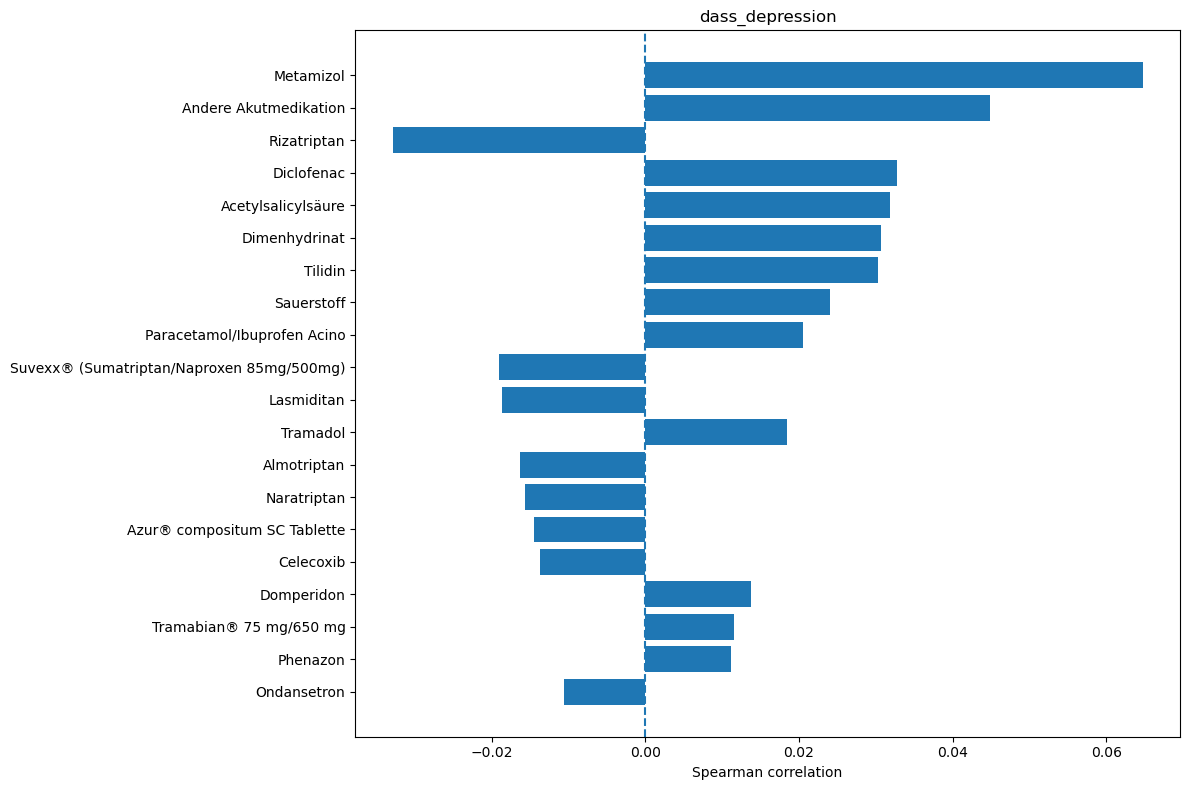


QUESTIONNAIRE: dass_fear
Y non-null: 17866
Valid correlations found: 49
Saved: correlation_plots\dass_fear_medication_correlation.png


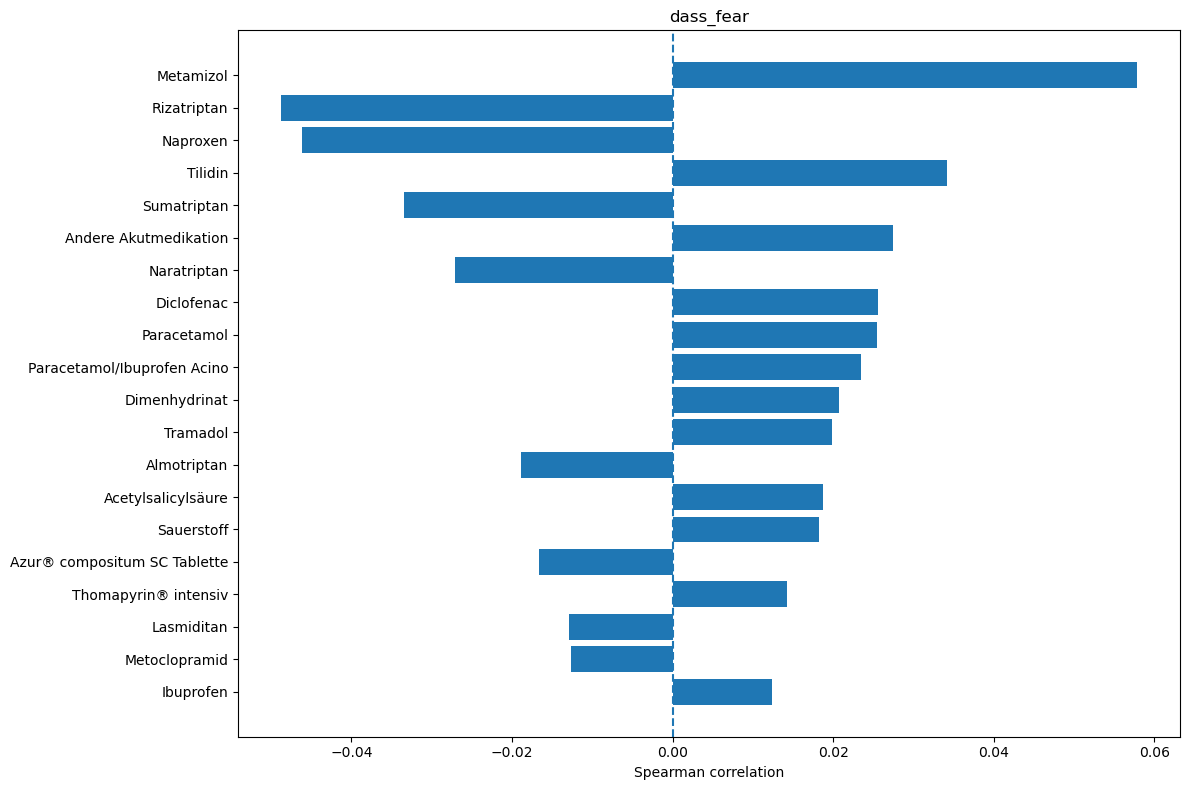


QUESTIONNAIRE: dass_stress
Y non-null: 17866
Valid correlations found: 49
Saved: correlation_plots\dass_stress_medication_correlation.png


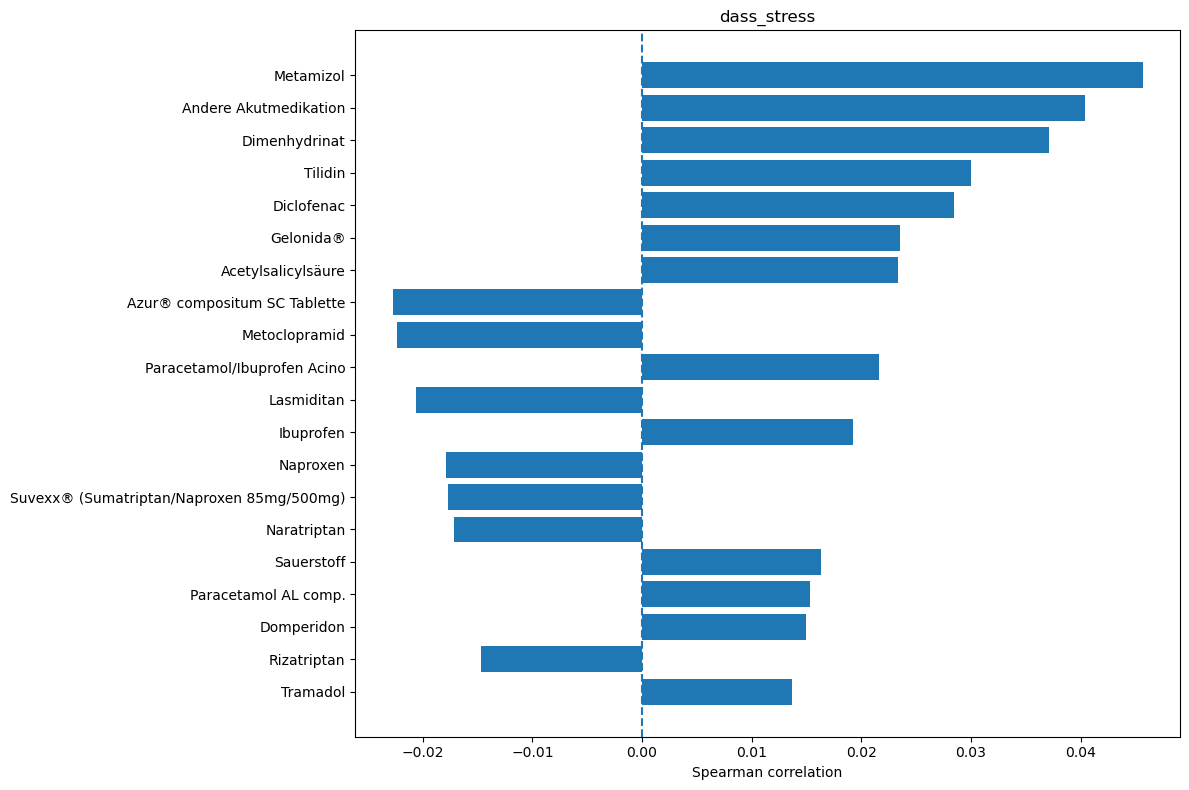


QUESTIONNAIRE: midas_result
Y non-null: 17866
Valid correlations found: 49
Saved: correlation_plots\midas_result_medication_correlation.png


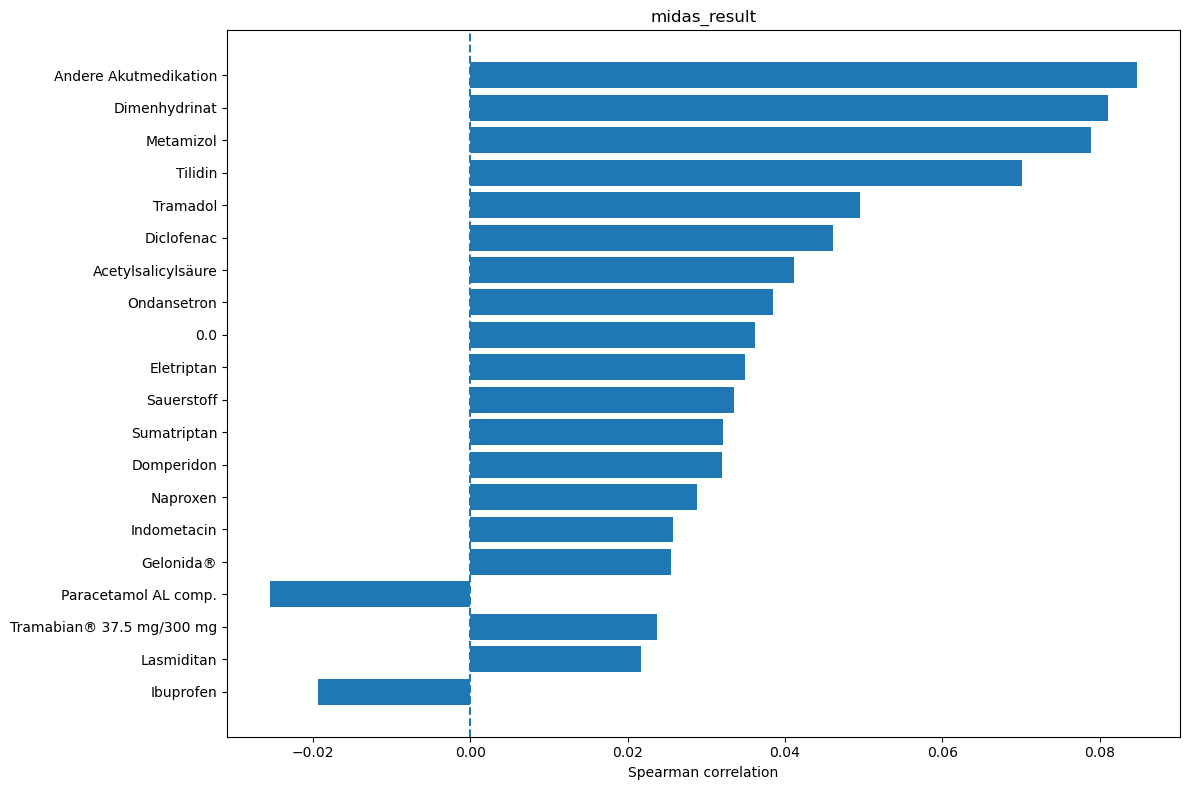


QUESTIONNAIRE: gvas_result
Y non-null: 17866
Valid correlations found: 49
Saved: correlation_plots\gvas_result_medication_correlation.png


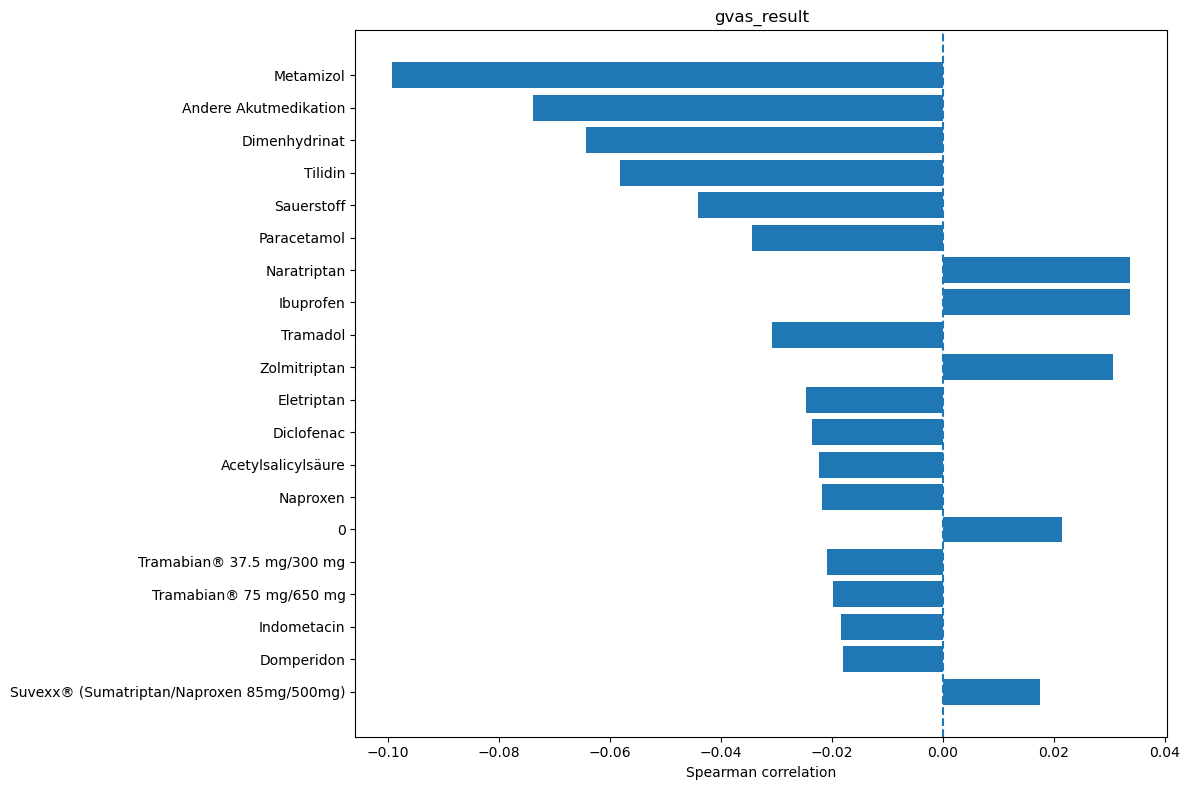


QUESTIONNAIRE: pgic_result
Y non-null: 11235


C:\Users\veron\AppData\Local\Temp\ipykernel_23960\511678144.py:30: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(


Valid correlations found: 48
Saved: correlation_plots\pgic_result_medication_correlation.png


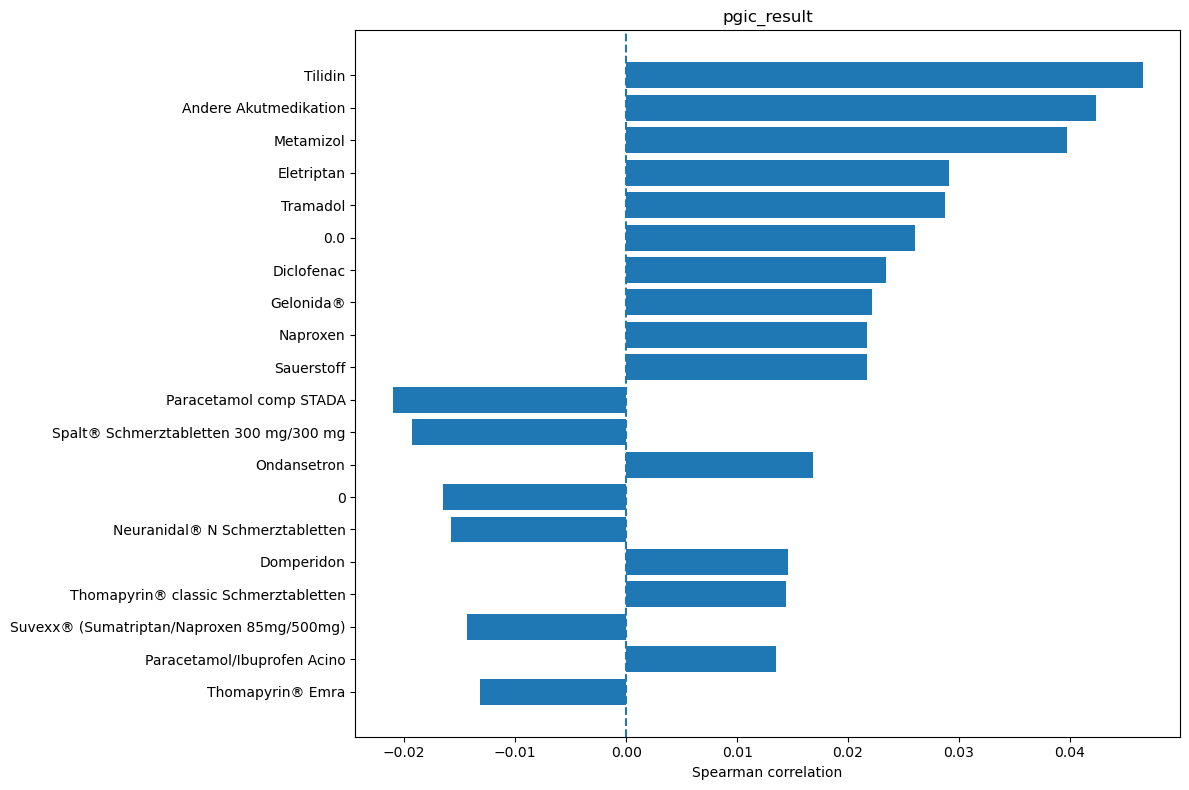


QUESTIONNAIRE: chiq_result
Y non-null: 192
Valid correlations found: 21


C:\Users\veron\AppData\Local\Temp\ipykernel_23960\511678144.py:30: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\veron\AppData\Local\Temp\ipykernel_23960\511678144.py:30: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\veron\AppData\Local\Temp\ipykernel_23960\511678144.py:30: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\veron\AppData\Local\Temp\ipykernel_23960\511678144.py:30: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\veron\AppData\Local\Temp\ipykernel_23960\511678144.py:30: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\veron\AppData\Local\Temp\ipykernel_23960\511678144.py:30: ConstantInput

Saved: correlation_plots\chiq_result_medication_correlation.png


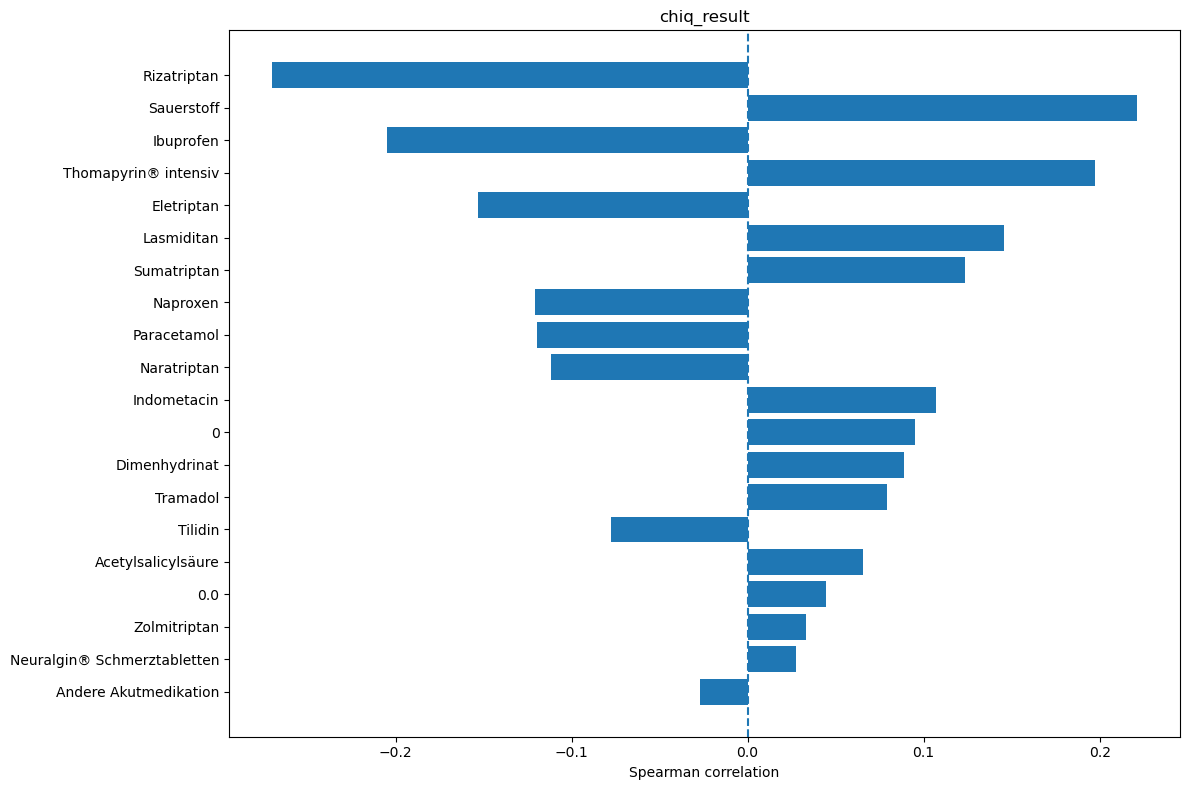

In [16]:
for questionnaire, y in combined_scores.items():

    print("\n" + "="*60)
    print("QUESTIONNAIRE:", questionnaire)
    print("="*60)

    y = pd.to_numeric(y, errors="coerce")

    print("Y non-null:", y.notna().sum())

    correlations = []

    for med in med_matrix.columns:

        x = med_matrix[med]

        # basic stats
        x_sum = x.sum()
        y_valid = ~(x.isna() | y.isna())
        n = y_valid.sum()

        # DEBUG OUTPUT (IMPORTANT)
        if x_sum < 5:
            continue

        if n < 10:
            continue

        try:
            corr, p = spearmanr(
                x[y_valid].astype(float),
                y[y_valid].astype(float)
            )

            if np.isnan(corr):
                continue

            correlations.append((med, corr))

        except Exception as e:
            print(f"FAILED {med}: {e}")

    print("Valid correlations found:", len(correlations))

    # ❗ THIS IS THE KEY FIX: do NOT silently skip plotting
    if len(correlations) == 0:
        print("NO DATA FOR PLOT → check missing values / overlap")
        continue

    correlations = sorted(
        correlations,
        key=lambda x: abs(x[1]),
        reverse=True
    )[:20]

    meds, vals = zip(*correlations)

    plt.figure(figsize=(12, max(6, len(meds) * 0.4)))

    plt.barh(meds[::-1], vals[::-1])

    plt.axvline(0, linestyle="--")

    plt.title(f"{questionnaire}")
    plt.xlabel("Spearman correlation")

    plt.tight_layout()

    import os

    SAVE_DIR = "correlation_plots"
    os.makedirs(SAVE_DIR, exist_ok=True)

    filename = f"{questionnaire}_medication_correlation.png"
    filepath = os.path.join(SAVE_DIR, filename)

    plt.savefig(filepath, dpi=200, bbox_inches="tight")
    print("Saved:", filepath)

    plt.show()